## Experiment 2 — CUDA Block Size Sweep


**Objective:** This experiment studies how the CUDA thread block size affects the performance of a vector addition kernel. The same naive CUDA vector-add implementation is executed using different block sizes, typically \(32, 64, 128, 256, 512,\) and \(1024\) threads per block, while keeping the input size fixed or testing across several large vector sizes. The goal is to measure kernel latency and effective memory bandwidth for each configuration, observe how block size influences warp utilization, occupancy, scheduling, and latency hiding, and determine whether larger block sizes necessarily improve performance. Since vector addition is primarily memory-bandwidth bound, the experiment also compares the achieved effective bandwidth against the GPU’s theoretical memory bandwidth.


## Implementation

In [27]:
!nvidia-smi

Sun Sep  6 22:29:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             26W /   70W |    1831MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Installing ninja library for load_inline run

In [28]:
!pip install ninja

In [29]:
# import libraries
import torch # for pytorch
from torch.utils.cpp_extension import load_inline # for loading cuda/c++ code
import matplotlib.pyplot as plt # for plotting
import time # for cpu timing

# versions
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")


PyTorch version: 2.11.0+cu128
CUDA available: True
cuDNN version: 91900


In [30]:
# define the vector size
n = 2**26 # defining a large vector size to test the performance of the kernels with different block sizes

block_sizes = [32, 64, 128, 256, 512, 1024] # defining the block sizes to test

I'll try to redo the kernels manually again (additional practice before going ahead)

Implementing naive CUDA add kernel

In [31]:
cpp_source="""

// include torch extension
#include <torch/extension.h>

// define the kernel host call as a prototype
torch::Tensor naive_cuda_add(torch::Tensor x, torch::Tensor y, int block_size);

"""

cuda_source = """

// include torch extension
#include <torch/extension.h>

// define the kernel
__global__ void naive_cuda_add_kernel(int n, const float* x, const float* y, float* output) {
    // get the thread id
    int tid = blockIdx.x * blockDim.x + threadIdx.x;

    // check if the thread id is less than the vector size
    if (tid < n) {
        output[tid] = x[tid] + y[tid];
    }
}

// define the kernel launcher
torch::Tensor naive_cuda_add(torch::Tensor x, torch::Tensor y, int block_size) {
    // checks:
    TORCH_CHECK(x.device().is_cuda(), "x must be a CUDA tensor");
    TORCH_CHECK(y.device().is_cuda(), "y must be a CUDA tensor");
    TORCH_CHECK(x.numel() == y.numel(), "x and y must have the same number of elements");

    // get the vector size
    int n = x.numel();

    // allocate the output tensor
    torch::Tensor output = torch::zeros_like(x);

    // get the number of blocks
    int num_blocks = (n+block_size-1)/block_size;
    
    // launch the kernel with the defined block configuration
    naive_cuda_add_kernel<<<num_blocks, block_size>>>(n, x.data_ptr<float>(), y.data_ptr<float>(), output.data_ptr<float>());

    // return the output tensor
    return output;
}

"""


In [33]:
module_block_size_sweep = load_inline(
    name="naive_block_size_sweep",
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    extra_cflags=["-O2"],
    functions=["naive_cuda_add"]
)


In [34]:
def benchmark(n, block_size):
    # create the random input tensors and load them to the GPU
    x = torch.randn(n, device="cuda", dtype=torch.float32)
    y = torch.randn(n, device="cuda", dtype=torch.float32)
    torch.cuda.synchronize()
    # use cuda events to record the start and end times
    start_naive = torch.cuda.Event(enable_timing=True)
    end_naive = torch.cuda.Event(enable_timing=True)
    start_torch = torch.cuda.Event(enable_timing=True)
    end_torch = torch.cuda.Event(enable_timing=True)
    
    # record the start time
    start_naive.record()
    # execute the naive kernel
    output_naive = module_block_size_sweep.naive_cuda_add(x, y, block_size)
    # record the end time
    end_naive.record()
    torch.cuda.synchronize()
    # get the elapsed time
    naive_time = start_naive.elapsed_time(end_naive)

    # execute the torch kernel
    start_torch.record()
    output_torch = torch.add(x, y)
    end_torch.record()
    torch.cuda.synchronize()
    # get the elapsed time
    torch_time = start_torch.elapsed_time(end_torch)
    
    return naive_time, torch_time


In [35]:
naive_time_array = []
torch_time_array = []

for block_size in block_sizes:
    naive_time, torch_time = benchmark(n, block_size)
    naive_time_array.append(naive_time)
    torch_time_array.append(torch_time)

effective_bandwidth_array = []
speedup_array = []

for i in range(len(block_sizes)):
    effective_bandwidth_array.append(n * 12 / naive_time_array[i] / 1e3)
    speedup_array.append(torch_time_array[i] / naive_time_array[i])


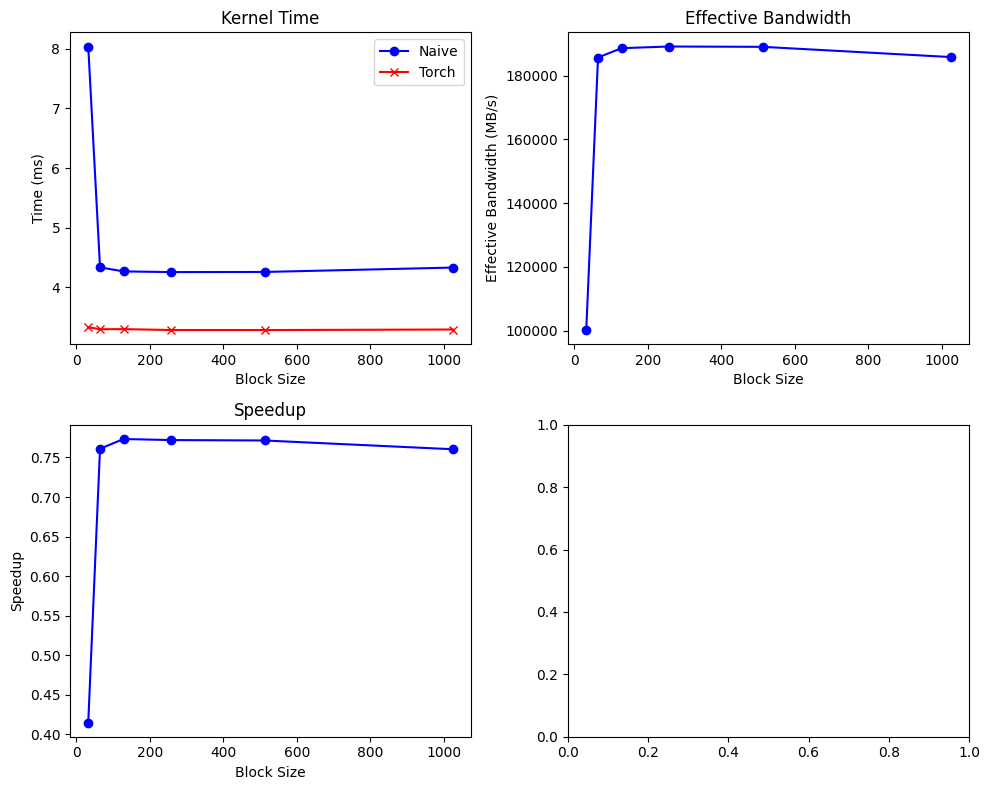

In [36]:
# plot the results
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# plot the naive and torch kernel times
axes[0, 0].plot(block_sizes, naive_time_array, marker='o', linestyle='-', color='blue')
axes[0, 0].plot(block_sizes, torch_time_array, marker='x', linestyle='-', color='red')

axes[0, 0].set_xlabel('Block Size')
axes[0, 0].set_ylabel('Time (ms)')
axes[0, 0].set_title('Kernel Time')
axes[0, 0].legend(['Naive', 'Torch'])

# plot the effective bandwidth
axes[0, 1].plot(block_sizes, effective_bandwidth_array, marker='o', linestyle='-', color='blue')
axes[0, 1].set_xlabel('Block Size')
axes[0, 1].set_ylabel('Effective Bandwidth (MB/s)')
axes[0, 1].set_title('Effective Bandwidth')

# plot the speedup
axes[1, 0].plot(block_sizes, speedup_array, marker='o', linestyle='-', color='blue')
axes[1, 0].set_xlabel('Block Size')
axes[1, 0].set_ylabel('Speedup')
axes[1, 0].set_title('Speedup')

plt.tight_layout()
plt.show()


- Block size **32** performed noticeably worse, with higher latency and lower effective bandwidth.
-  Performance improved strongly by **64–128 threads per block**.
- Block sizes around **128–512** gave nearly identical performance, suggesting a broad sweet spot rather than one exact optimal size.
- At **1024 threads**, performance dropped slightly.
- Once enough warps are available for latency hiding, larger blocks provide little extra benefit because vector addition is mainly **memory-bandwidth bound**.
- An effective bandwidth of about **190,000 MB/s ≈ 190 GB/s**.
- PyTorch `torch.add` remained faster than the naive CUDA kernel across the tested block sizes.
